# Executive Summary

This notebook analyses the CBS labour market dataset 85916NED, covering quarterly labour indicators for the Netherlands between 2010 and 2025. The analysis focuses on workforce size, labour intensity, gender participation, and worker type composition.

The results show steady labour market growth, increasing female labour participation, and a stable workforce structure dominated by employees. While employment levels change gradually over time, working hours exhibit strong seasonal patterns, with lower activity in the summer (Q3) and higher activity toward the end of the year (Q4).

These indicators provide useful macro labour market features that may help explain and model sick leave and absenteeism patterns.

# Cleaning 85916NED Data

This notebook will load, clean, and visualize the 85916NED dataset from the project data folder.

## 1. Import required libraries

In [ ]:
# Import required libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Reading the table from Silver Database

In [2]:
from pathlib import Path
import sqlite3
import pandas as pd

# Path to the silver database
db_path = Path("../data/2_silver/silver_data.db")

# Connect to the database
conn = sqlite3.connect(db_path)
print(f"Connected to {db_path}")

# List available tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print("Available tables:", tables["name"].tolist())

# Read the table (IMPORTANT: quote table name because it starts with a number)
table_name = "85916NED_silver"

df_85916NED = pd.read_sql_query(
    f'SELECT * FROM "{table_name}"',
    conn
)

print(f"Loaded {len(df_85916NED)} rows from {table_name}")
display(df_85916NED.head())

Connected to ..\data\2_silver\silver_data.db
Available tables: ['85920NED_silver_SH', '85920NED_silver', '85916NED_silver']
Loaded 720 rows from 85916NED_silver


,silver_id,bronze_pk,ID,TypeWerkenden,Geslacht,Perioden,WerkzamePersonen_1,Banen_2,GewerkteUren_3,GewerkteUrenPerWerkzamePersoon_4,...,_source_file,Geslacht_Title,Geslacht_Description,Geslacht_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status,TypeWerkenden_Title,TypeWerkenden_Description,TypeWerkenden_CategoryGroupID
0,1,TypedDataSet.json_0,0,T001413,T001038,2010KW01,8689.0,9727.0,3180.0,366,...,TypedDataSet.json,Totaal mannen en vrouwen,,None,2010 1e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
1,2,TypedDataSet.json_1,1,T001413,T001038,2010KW02,8800.0,9876.0,2952.0,335,...,TypedDataSet.json,Totaal mannen en vrouwen,,None,2010 2e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
2,3,TypedDataSet.json_2,2,T001413,T001038,2010KW03,8821.0,9875.0,3027.0,343,...,TypedDataSet.json,Totaal mannen en vrouwen,,None,2010 3e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
3,4,TypedDataSet.json_3,3,T001413,T001038,2010KW04,8804.0,9850.0,3396.0,386,...,TypedDataSet.json,Totaal mannen en vrouwen,,None,2010 4e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None
4,5,TypedDataSet.json_4,4,T001413,T001038,2010JJ00,8779.0,9832.0,12555.0,1430,...,TypedDataSet.json,Totaal mannen en vrouwen,,None,2010,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,None


## 3. Data Cleaning

### Standardize column data types for the full table

In [6]:
# --- Standardize column data types for the full table ---


# 1. Convert key / ID columns
df_85916NED["silver_id"] = df_85916NED["silver_id"].astype("int64")
df_85916NED["bronze_pk"] = df_85916NED["bronze_pk"].astype("string")
df_85916NED["ID"] = df_85916NED["ID"].astype("string")


# 2. Convert dimension code columns
dim_cols = [
    "TypeWerkenden",
    "Geslacht",
    "Perioden"
]

df_85916NED[dim_cols] = df_85916NED[dim_cols].astype("string")


# 3. Convert descriptive text columns
text_cols = [
    "Geslacht_Title",
    "Geslacht_Description",
    "Perioden_Title",
    "Perioden_Description",
    "Perioden_Status",
    "TypeWerkenden_Title",
    "TypeWerkenden_Description",
    "_source_file"
]

df_85916NED[text_cols] = df_85916NED[text_cols].astype("string")


# 4. Convert numeric CBS variables
numeric_cols = [
    "WerkzamePersonen_1",
    "Banen_2",
    "GewerkteUren_3",
    "GewerkteUrenPerWerkzamePersoon_4",
    "GewerkteUrenPerBaan_5",
    "WerkzamePersonen_6",
    "Banen_7",
    "GewerkteUren_8",
    "GewerkteUrenPerWerkzamePersoon_9",
    "GewerkteUrenPerBaan_10"
]

df_85916NED[numeric_cols] = df_85916NED[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)


# 5. Convert remaining category columns
remaining_cols = [
    "Geslacht_CategoryGroupID",
    "TypeWerkenden_CategoryGroupID"
]

df_85916NED[remaining_cols] = df_85916NED[remaining_cols].astype("string")


# 6. Final check
df_85916NED.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   silver_id                         720 non-null    int64  
 1   bronze_pk                         720 non-null    string 
 2   ID                                720 non-null    string 
 3   TypeWerkenden                     720 non-null    string 
 4   Geslacht                          720 non-null    string 
 5   Perioden                          720 non-null    string 
 6   WerkzamePersonen_1                720 non-null    float64
 7   Banen_2                           720 non-null    float64
 8   GewerkteUren_3                    720 non-null    float64
 9   GewerkteUrenPerWerkzamePersoon_4  720 non-null    int64  
 10  GewerkteUrenPerBaan_5             720 non-null    int64  
 11  WerkzamePersonen_6                576 non-null    float64
 12  Banen_7 

### Convert CBS Perioden codes into datetime + frequency

In [7]:
# --- Standard CBS Perioden → time dimension conversion ---


# 1. Determine frequency
df_85916NED["frequency"] = np.select(
    [
        df_85916NED["Perioden"].str.contains("KW"),
        df_85916NED["Perioden"].str.contains("MM"),
        df_85916NED["Perioden"].str.contains("JJ")
    ],
    [
        "quarterly",
        "monthly",
        "annual"
    ],
    default="unknown"
)


# 2. Extract year
df_85916NED["year"] = df_85916NED["Perioden"].str[:4].astype(int)


# 3. Extract quarter
df_85916NED["quarter"] = df_85916NED["Perioden"].str.extract(r"KW(\d{2})")[0]
df_85916NED["quarter"] = pd.to_numeric(df_85916NED["quarter"], errors="coerce")


# 4. Create empty datetime column
df_85916NED["period_enddate"] = pd.NaT


# --- Quarterly periods ---
mask_q = df_85916NED["frequency"] == "quarterly"

df_85916NED.loc[mask_q, "period_enddate"] = (
    pd.PeriodIndex(
        year=df_85916NED.loc[mask_q, "year"],
        quarter=df_85916NED.loc[mask_q, "quarter"].astype(int)
    )
    .to_timestamp(how="end")
)


# --- Annual periods ---
mask_y = df_85916NED["frequency"] == "annual"

df_85916NED.loc[mask_y, "period_enddate"] = pd.to_datetime(
    df_85916NED.loc[mask_y, "year"].astype(str) + "-12-31"
)


# --- Monthly periods (future-proof) ---
mask_m = df_85916NED["frequency"] == "monthly"

month = df_85916NED.loc[mask_m, "Perioden"].str.extract(r"MM(\d{2})")[0]
month = pd.to_numeric(month, errors="coerce")

df_85916NED.loc[mask_m, "period_enddate"] = (
    pd.to_datetime(dict(
        year=df_85916NED.loc[mask_m, "year"],
        month=month,
        day=1
    )) + pd.offsets.MonthEnd(0)
)


# 5. Clean timestamp precision
df_85916NED["period_enddate"] = pd.to_datetime(df_85916NED["period_enddate"]).dt.normalize()


# 6. Convert quarter to nullable integer
df_85916NED["quarter"] = df_85916NED["quarter"].astype("Int64")


# 7. Check result
df_85916NED[["Perioden", "frequency", "year", "quarter", "period_enddate"]].head(10)

C:\Users\gebruiker\AppData\Local\Temp\ipykernel_21976\2418969484.py:37: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  pd.PeriodIndex(


,Perioden,frequency,year,quarter,period_enddate
0,2010KW01,quarterly,2010,1,2010-03-31
1,2010KW02,quarterly,2010,2,2010-06-30
2,2010KW03,quarterly,2010,3,2010-09-30
3,2010KW04,quarterly,2010,4,2010-12-31
4,2010JJ00,annual,2010,<NA>,2010-12-31
5,2011KW01,quarterly,2011,1,2011-03-31
6,2011KW02,quarterly,2011,2,2011-06-30
7,2011KW03,quarterly,2011,3,2011-09-30
8,2011KW04,quarterly,2011,4,2011-12-31
9,2011JJ00,annual,2011,<NA>,2011-12-31


### DataFrame structural cleaning

In [8]:
# --- DataFrame structural cleaning ---


# 1. Rename numeric columns for clarity
df_85916NED = df_85916NED.rename(columns={

    "WerkzamePersonen_1": "WerkzamePersonen",
    "Banen_2": "Banen",
    "GewerkteUren_3": "GewerkteUren",
    "GewerkteUrenPerWerkzamePersoon_4": "GewerkteUrenPerWerkzamePersoon",
    "GewerkteUrenPerBaan_5": "GewerkteUrenPerBaan",

    "WerkzamePersonen_6": "WerkzamePersonenSeizoengecorrigeerd",
    "Banen_7": "BanenSeizoengecorrigeerd",
    "GewerkteUren_8": "GewerkteUrenSeizoengecorrigeerd",
    "GewerkteUrenPerWerkzamePersoon_9": "GewerkteUrenPerWerkzamePersoonSeizoengecorrigeerd",
    "GewerkteUrenPerBaan_10": "GewerkteUrenPerBaanSeizoengecorrigeerd"
})


# 2. Reorder columns (bring time fields after Perioden)

cols = list(df_85916NED.columns)

cols.remove("frequency")
cols.remove("year")
cols.remove("quarter")
cols.remove("period_enddate")

period_index = cols.index("Perioden")

new_cols = (
    cols[:period_index + 1] +
    ["frequency", "year", "quarter", "period_enddate"] +
    cols[period_index + 1:]
)

df_85916NED = df_85916NED[new_cols]


# 3. Verify result
df_85916NED.columns
df_85916NED.head()

,silver_id,bronze_pk,ID,TypeWerkenden,Geslacht,Perioden,frequency,year,quarter,period_enddate,...,_source_file,Geslacht_Title,Geslacht_Description,Geslacht_CategoryGroupID,Perioden_Title,Perioden_Description,Perioden_Status,TypeWerkenden_Title,TypeWerkenden_Description,TypeWerkenden_CategoryGroupID
0,1,TypedDataSet.json_0,0,T001413,T001038,2010KW01,quarterly,2010,1,2010-03-31,...,TypedDataSet.json,Totaal mannen en vrouwen,,<NA>,2010 1e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>
1,2,TypedDataSet.json_1,1,T001413,T001038,2010KW02,quarterly,2010,2,2010-06-30,...,TypedDataSet.json,Totaal mannen en vrouwen,,<NA>,2010 2e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>
2,3,TypedDataSet.json_2,2,T001413,T001038,2010KW03,quarterly,2010,3,2010-09-30,...,TypedDataSet.json,Totaal mannen en vrouwen,,<NA>,2010 3e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>
3,4,TypedDataSet.json_3,3,T001413,T001038,2010KW04,quarterly,2010,4,2010-12-31,...,TypedDataSet.json,Totaal mannen en vrouwen,,<NA>,2010 4e kwartaal,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>
4,5,TypedDataSet.json_4,4,T001413,T001038,2010JJ00,annual,2010,<NA>,2010-12-31,...,TypedDataSet.json,Totaal mannen en vrouwen,,<NA>,2010,,Definitief,Totaal,Het totaal van de werknemers en zelfstandigen.,<NA>


## 4. Uploading the new data table to Silver Database

In [9]:
# --- Save cleaned table to Silver database ---

df_85916NED.to_sql(
    "85916NED_silver_SH",
    conn,
    if_exists="replace",
    index=False
)


# --- Validate the saved table ---

df_check = pd.read_sql_query(
    'SELECT * FROM "85916NED_silver_SH"',
    conn
)

print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])

df_check.head()

df_check.dtypes

df_check.isna().sum()

Rows: 720
Columns: 30


silver_id                                              0
bronze_pk                                              0
ID                                                     0
TypeWerkenden                                          0
Geslacht                                               0
Perioden                                               0
frequency                                              0
year                                                   0
quarter                                              144
period_enddate                                         0
WerkzamePersonen                                       0
Banen                                                  0
GewerkteUren                                           0
GewerkteUrenPerWerkzamePersoon                         0
GewerkteUrenPerBaan                                    0
WerkzamePersonenSeizoengecorrigeerd                  144
BanenSeizoengecorrigeerd                             144
GewerkteUrenSeizoengecorrigeerd

# Data Exploration

### raeding the clean table for EDA

In [10]:
# Load cleaned table from the Silver database
df_85916NED_clean = pd.read_sql_query(
    'SELECT * FROM "85916NED_silver_SH"',
    conn
)

# Quick validation
print("Rows:", df_85916NED_clean.shape[0])
print("Columns:", df_85916NED_clean.shape[1])

df_85916NED_clean.head()
df_85916NED_clean.info()
df_85916NED_clean.describe()
df_85916NED_clean.isna().sum().sort_values(ascending=False)




Rows: 720
Columns: 30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 30 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   silver_id                                          720 non-null    int64  
 1   bronze_pk                                          720 non-null    object 
 2   ID                                                 720 non-null    object 
 3   TypeWerkenden                                      720 non-null    object 
 4   Geslacht                                           720 non-null    object 
 5   Perioden                                           720 non-null    object 
 6   frequency                                          720 non-null    object 
 7   year                                               720 non-null    int64  
 8   quarter                                            576 non-null    f

Geslacht_CategoryGroupID                             720
TypeWerkenden_CategoryGroupID                        720
BanenSeizoengecorrigeerd                             144
WerkzamePersonenSeizoengecorrigeerd                  144
quarter                                              144
GewerkteUrenPerBaanSeizoengecorrigeerd               144
GewerkteUrenPerWerkzamePersoonSeizoengecorrigeerd    144
GewerkteUrenSeizoengecorrigeerd                      144
Perioden                                               0
silver_id                                              0
ID                                                     0
TypeWerkenden                                          0
Geslacht                                               0
bronze_pk                                              0
GewerkteUrenPerWerkzamePersoon                         0
GewerkteUren                                           0
Banen                                                  0
WerkzamePersonen               

In [11]:
# -----------------------------
# Fix datatypes for analysis
# -----------------------------


# 1. Date column
df_85916NED_clean["period_enddate"] = pd.to_datetime(df_85916NED_clean["period_enddate"])


# 2. Integer columns
df_85916NED_clean["silver_id"] = df_85916NED_clean["silver_id"].astype("int64")
df_85916NED_clean["year"] = df_85916NED_clean["year"].astype("int64")

# quarter contains missing values -> nullable integer
df_85916NED_clean["quarter"] = df_85916NED_clean["quarter"].astype("Int64")


# 3. Numeric variables (labour indicators)
numeric_cols = [
    "WerkzamePersonen",
    "Banen",
    "GewerkteUren",
    "GewerkteUrenPerWerkzamePersoon",
    "GewerkteUrenPerBaan",
    "WerkzamePersonenSeizoengecorrigeerd",
    "BanenSeizoengecorrigeerd",
    "GewerkteUrenSeizoengecorrigeerd",
    "GewerkteUrenPerWerkzamePersoonSeizoengecorrigeerd",
    "GewerkteUrenPerBaanSeizoengecorrigeerd"
]

df_85916NED_clean[numeric_cols] = df_85916NED_clean[numeric_cols].astype("float64")


# 4. Categorical variables (few repeated values)
category_cols = [
    "TypeWerkenden",
    "Geslacht",
    "frequency",
    "Perioden_Status",
    "TypeWerkenden_Title",
    "Geslacht_Title"
]

df_85916NED_clean[category_cols] = df_85916NED_clean[category_cols].astype("category")


# 5. String / identifier fields
string_cols = [
    "bronze_pk",
    "ID",
    "Perioden",
    "_source_file",
    "Perioden_Title",
    "Perioden_Description",
    "TypeWerkenden_Description",
    "Geslacht_Description",
    "Geslacht_CategoryGroupID",
    "TypeWerkenden_CategoryGroupID"
]

df_85916NED_clean[string_cols] = df_85916NED_clean[string_cols].astype("string")


# 6. Verify
df_85916NED_clean.dtypes

silver_id                                                     int64
bronze_pk                                            string[python]
ID                                                   string[python]
TypeWerkenden                                              category
Geslacht                                                   category
Perioden                                             string[python]
frequency                                                  category
year                                                          int64
quarter                                                       Int64
period_enddate                                       datetime64[ns]
WerkzamePersonen                                            float64
Banen                                                       float64
GewerkteUren                                                float64
GewerkteUrenPerWerkzamePersoon                              float64
GewerkteUrenPerBaan                             

### Dataset Overview

Rows: 720
Columns: 30

Time coverage:
Start: 2010-03-31 00:00:00
End: 2025-12-31 00:00:00

Frequency distribution:
frequency
quarterly    576
annual       144
Name: count, dtype: int64

Worker type distribution:
TypeWerkenden_Title
Totaal           240
Werknemers       240
Zelfstandigen    240
Name: count, dtype: int64

Gender distribution:
Geslacht_Title
Mannen                      240
Totaal mannen en vrouwen    240
Vrouwen                     240
Name: count, dtype: int64

Gender categories:
['Totaal mannen en vrouwen', 'Mannen', 'Vrouwen']
Categories (3, object): ['Mannen', 'Totaal mannen en vrouwen', 'Vrouwen']

Missing values per column:
Geslacht_CategoryGroupID                             720
TypeWerkenden_CategoryGroupID                        720
BanenSeizoengecorrigeerd                             144
WerkzamePersonenSeizoengecorrigeerd                  144
quarter                                              144
GewerkteUrenPerBaanSeizoengecorrigeerd               144
Gewerk

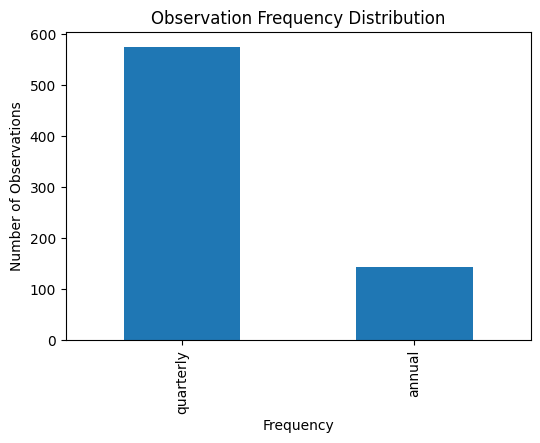

TypeWerkenden_Title  Geslacht_Title          
Totaal               Mannen                      80
                     Totaal mannen en vrouwen    80
                     Vrouwen                     80
Werknemers           Mannen                      80
                     Totaal mannen en vrouwen    80
                     Vrouwen                     80
Zelfstandigen        Mannen                      80
                     Totaal mannen en vrouwen    80
                     Vrouwen                     80
dtype: int64

In [14]:
# 1. Dataset size
print("Rows:", df_85916NED_clean.shape[0])
print("Columns:", df_85916NED_clean.shape[1])

# 2. Time coverage
print("\nTime coverage:")
print("Start:", df_85916NED_clean["period_enddate"].min())
print("End:", df_85916NED_clean["period_enddate"].max())

# 3. Frequency distribution
print("\nFrequency distribution:")
print(df_85916NED_clean["frequency"].value_counts())

# 4. Worker type distribution
print("\nWorker type distribution:")
print(df_85916NED_clean["TypeWerkenden_Title"].value_counts())

# 5. Gender coverage
print("\nGender distribution:")
print(df_85916NED_clean["Geslacht_Title"].value_counts())

print("\nGender categories:")
print(df_85916NED_clean["Geslacht_Title"].unique())

# 6. Missing values overview
print("\nMissing values per column:")
print(df_85916NED_clean.isna().sum().sort_values(ascending=False))

# 7. Quick visualization of frequency distribution
plt.figure(figsize=(6,4))
df_85916NED_clean["frequency"].value_counts().plot(kind="bar")
plt.title("Observation Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Number of Observations")
plt.show()

# 8. Check grouping

df_85916NED_clean.groupby(
    ["TypeWerkenden_Title","Geslacht_Title"],
    observed=False
).size()

#### Interpretation (Dataset Overview)

Dataset Size

The cleaned dataset contains 720 observations and 30 variables describing labour volume indicators in the Netherlands.
Each observation represents a combination of time period, worker type, and gender category.

Time Coverage

The dataset covers the period from 2010 to 2025, with the earliest observation dated 2010-03-31 and the latest observation 2025-12-31.
This provides approximately 15 years of labour market history, which is sufficient for analyzing long-term trends and seasonal patterns in employment and working hours.

Temporal Frequency

The dataset contains two different temporal resolutions:

Quarterly observations: 576

Annual observations: 144

Quarterly data represents the majority of the dataset and is the most useful for time-series analysis.
Annual observations provide aggregated yearly values that complement the quarterly series.

Worker Type Distribution

The dataset includes three categories of workers:

Totaal – Total workforce

Werknemers – Employees

Zelfstandigen – Self-employed workers

Each worker type contains 240 observations, indicating that the dataset is balanced across worker categories.

Gender Distribution

The gender dimension contains three categories:

Mannen – Male workers

Vrouwen – Female workers

Totaal mannen en vrouwen – Combined total

Each gender category also contains 240 observations, confirming that the dataset is balanced across gender groups.

Panel Structure

Combining the worker type and gender dimensions results in nine unique category combinations:

3 worker types

3 gender categories

Each combination contains 80 observations, meaning the dataset forms a balanced panel dataset.
This structure is beneficial for time-series analysis and comparative studies between groups.

Missing Values

The missing value analysis reveals two main patterns:

CategoryGroupID columns contain only missing values.
These fields are metadata from the CBS dataset and are not relevant for analytical purposes.

Seasonally adjusted variables (e.g., BanenSeizoengecorrigeerd, WerkzamePersonenSeizoengecorrigeerd) contain 144 missing values.
These missing values correspond to annual observations, as seasonal adjustment is typically applied only to quarterly data.

Additionally, the quarter variable contains 144 missing values because annual observations do not have a quarter identifier.

Summary

Overall, the dataset is clean, balanced, and well structured, with consistent observations across worker types, gender categories, and time periods.
The presence of both quarterly and annual data provides flexibility for different types of analyses, including time-series trend analysis and labour market comparisons across demographic groups.

### Workforce Structure Overview

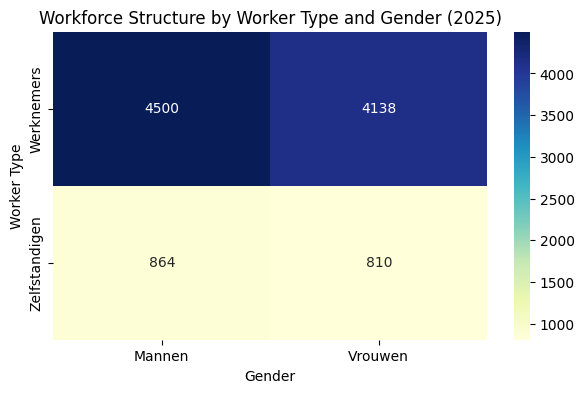

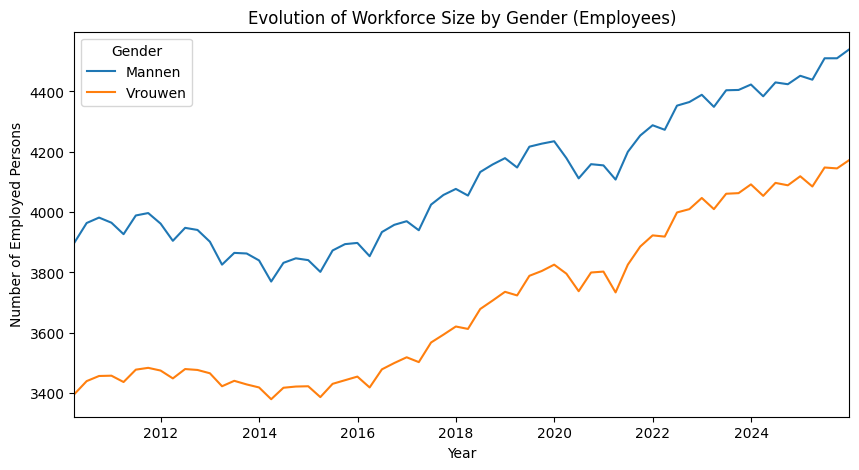

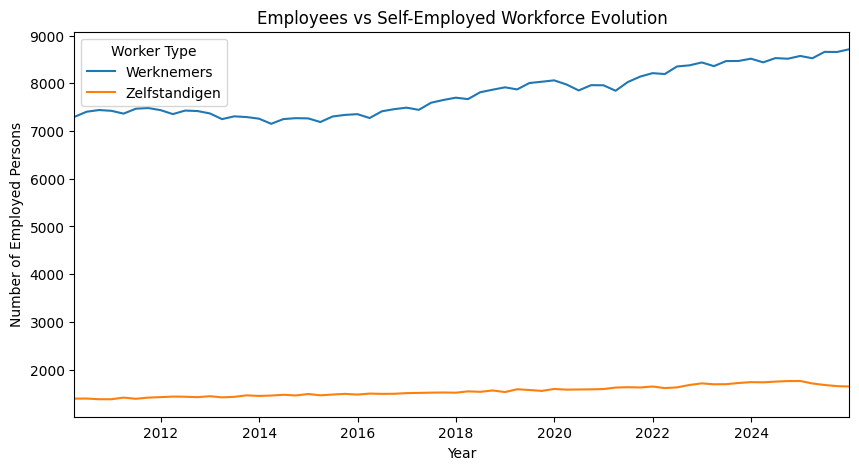

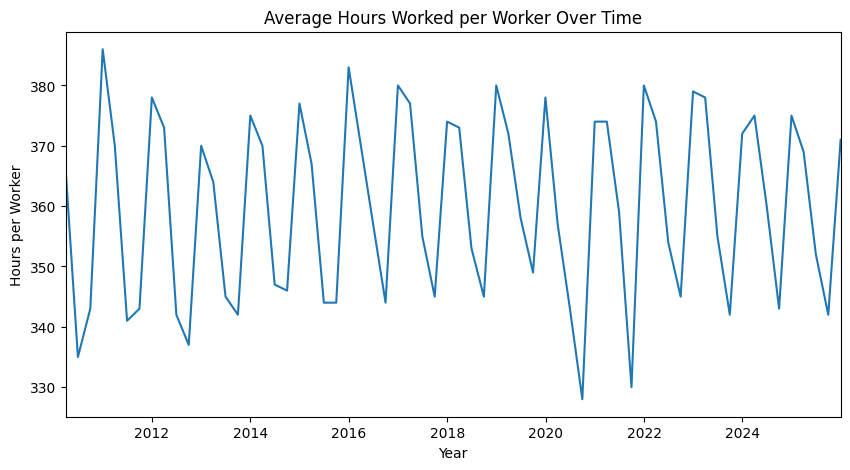

<Figure size 1000x500 with 0 Axes>

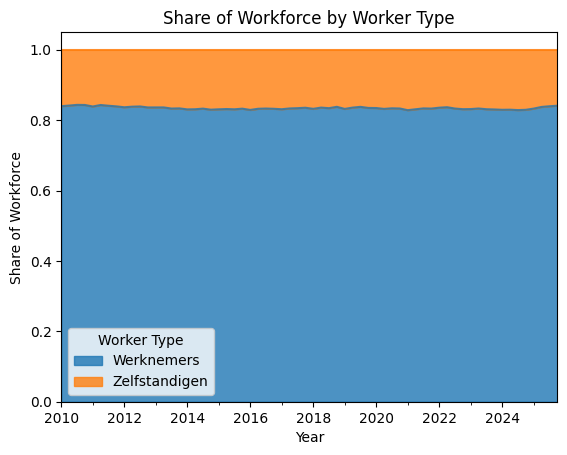

In [19]:
# ==========================================================
# Labour Market Structure & Trends
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Workforce structure snapshot (latest year)
# ----------------------------------------------------------

df_structure = df_85916NED_clean[
    (df_85916NED_clean["Geslacht_Title"].isin(["Mannen","Vrouwen"])) &
    (df_85916NED_clean["TypeWerkenden_Title"].isin(["Werknemers","Zelfstandigen"])) &
    (df_85916NED_clean["frequency"] == "quarterly")
].copy()

# Remove unused categories
df_structure["Geslacht_Title"] = df_structure["Geslacht_Title"].cat.remove_unused_categories()
df_structure["TypeWerkenden_Title"] = df_structure["TypeWerkenden_Title"].cat.remove_unused_categories()

latest_year = df_structure["year"].max()

df_latest = df_structure[df_structure["year"] == latest_year]

structure_table = df_latest.pivot_table(
    values="WerkzamePersonen",
    index="TypeWerkenden_Title",
    columns="Geslacht_Title",
    aggfunc="mean",
    observed=False
)

plt.figure(figsize=(7,4))

sns.heatmap(
    structure_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title(f"Workforce Structure by Worker Type and Gender ({latest_year})")
plt.xlabel("Gender")
plt.ylabel("Worker Type")

plt.show()


# ----------------------------------------------------------
# 2. Workforce evolution by gender (employees)
# ----------------------------------------------------------

df_gender = df_85916NED_clean[
    (df_85916NED_clean["Geslacht_Title"].isin(["Mannen","Vrouwen"])) &
    (df_85916NED_clean["TypeWerkenden_Title"] == "Werknemers") &
    (df_85916NED_clean["frequency"] == "quarterly")
].copy()

df_gender["Geslacht_Title"] = df_gender["Geslacht_Title"].cat.remove_unused_categories()

df_gender = df_gender.groupby(
    ["period_enddate","Geslacht_Title"],
    observed=False
)["WerkzamePersonen"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_gender,
    x="period_enddate",
    y="WerkzamePersonen",
    hue="Geslacht_Title"
)

plt.title("Evolution of Workforce Size by Gender (Employees)")
plt.xlabel("Year")
plt.ylabel("Number of Employed Persons")

plt.xlim(df_gender["period_enddate"].min(),
         df_gender["period_enddate"].max())

plt.legend(title="Gender")

plt.show()


# ----------------------------------------------------------
# 3. Employees vs Self-Employed evolution
# ----------------------------------------------------------

df_worker_type = df_85916NED_clean[
    (df_85916NED_clean["Geslacht_Title"] == "Totaal mannen en vrouwen") &
    (df_85916NED_clean["TypeWerkenden_Title"].isin(["Werknemers","Zelfstandigen"])) &
    (df_85916NED_clean["frequency"] == "quarterly")
].copy()

df_worker_type["TypeWerkenden_Title"] = df_worker_type["TypeWerkenden_Title"].cat.remove_unused_categories()

df_worker_type = df_worker_type.groupby(
    ["period_enddate","TypeWerkenden_Title"],
    observed=False
)["WerkzamePersonen"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_worker_type,
    x="period_enddate",
    y="WerkzamePersonen",
    hue="TypeWerkenden_Title"
)

plt.title("Employees vs Self-Employed Workforce Evolution")
plt.xlabel("Year")
plt.ylabel("Number of Employed Persons")

plt.xlim(df_worker_type["period_enddate"].min(),
         df_worker_type["period_enddate"].max())

plt.legend(title="Worker Type")

plt.show()


# ----------------------------------------------------------
# 4. Work intensity trend (hours per worker)
# ----------------------------------------------------------

df_hours = df_85916NED_clean[
    (df_85916NED_clean["Geslacht_Title"] == "Totaal mannen en vrouwen") &
    (df_85916NED_clean["TypeWerkenden_Title"] == "Totaal") &
    (df_85916NED_clean["frequency"] == "quarterly")
].copy()

df_hours = df_hours.groupby(
    "period_enddate",
    observed=False
)["GewerkteUrenPerWerkzamePersoon"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_hours,
    x="period_enddate",
    y="GewerkteUrenPerWerkzamePersoon"
)

plt.title("Average Hours Worked per Worker Over Time")
plt.xlabel("Year")
plt.ylabel("Hours per Worker")

plt.xlim(df_hours["period_enddate"].min(),
         df_hours["period_enddate"].max())

plt.show()

# ----------------------------------------------------------
# Worker type share over time
# ----------------------------------------------------------

df_share = df_85916NED_clean[
    (df_85916NED_clean["Geslacht_Title"] == "Totaal mannen en vrouwen") &
    (df_85916NED_clean["TypeWerkenden_Title"].isin(["Werknemers","Zelfstandigen"])) &
    (df_85916NED_clean["frequency"] == "quarterly")
].copy()

df_share = df_share.pivot_table(
    values="WerkzamePersonen",
    index="period_enddate",
    columns="TypeWerkenden_Title",
    observed=False
)

# Calculate shares
df_share = df_share.div(df_share.sum(axis=1), axis=0)

plt.figure(figsize=(10,5))

df_share.plot.area(
    stacked=True,
    alpha=0.8
)

plt.title("Share of Workforce by Worker Type")
plt.xlabel("Year")
plt.ylabel("Share of Workforce")

plt.legend(title="Worker Type")

plt.show()

#### Interpretation – Labour Market Structure and Trends

The analysis of labour volume indicators reveals several important trends in the Dutch labour market over the period 2010–2025.

Workforce Structure

The Dutch labour market is predominantly composed of employees. In the most recent year of the dataset (2025), approximately 4.5 million men and 4.1 million women are employed as employees, while the number of self-employed workers is significantly smaller, with around 864 thousand men and 810 thousand women. This indicates that although self-employment represents a meaningful segment of the labour market, the majority of workers are employed under traditional employment contracts.

Gender Participation Trends

The time-series analysis shows a steady increase in employment for both men and women since around 2015. While male employment remains slightly higher overall, female employment has grown at a faster rate during the observed period. This suggests a gradual narrowing of the gender employment gap, reflecting increasing female participation in the Dutch labour market.

Employees vs Self-Employment

Both employees and self-employed workers have increased in absolute numbers over the past decade. However, the growth in the number of employees has been more pronounced, rising from roughly 7.4 million in 2010 to around 8.7 million in 2025. Self-employment has increased more modestly, from approximately 1.4 million to about 1.7 million workers during the same period. As a result, the labour market continues to be strongly dominated by employees.

Stability of Workforce Composition

Despite the growth in both employment categories, the overall composition of the labour market has remained relatively stable. Employees consistently represent approximately 83–85% of the workforce, while self-employed workers account for roughly 15–17%. This indicates that the increase in self-employment has occurred proportionally with the growth of the workforce rather than fundamentally changing its structure.

Work Intensity and Seasonal Patterns

The analysis of the average number of hours worked per worker shows a clear seasonal pattern, with recurring peaks and troughs each year. This reflects seasonal fluctuations in labour demand across the economy. A noticeable drop in working hours is visible around 2020–2021, likely associated with the economic disruptions caused by the COVID-19 pandemic. Following this period, working hours gradually recover toward pre-pandemic levels.

Overall Labour Market Dynamics

Taken together, these findings indicate that the Dutch labour market has experienced steady expansion over the past decade, accompanied by increasing female labour participation and stable workforce composition. While self-employment has grown slightly, the labour market remains largely dominated by employees. Additionally, labour intensity exhibits strong seasonal patterns, highlighting the importance of accounting for seasonal effects when analyzing labour market dynamics.

### Seasonality Analysis

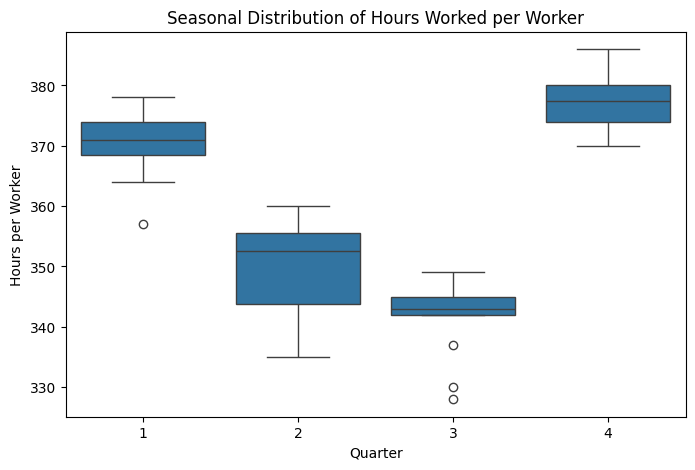

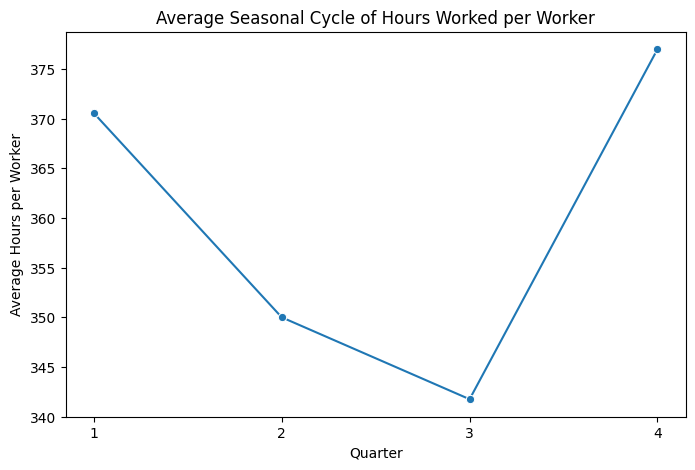

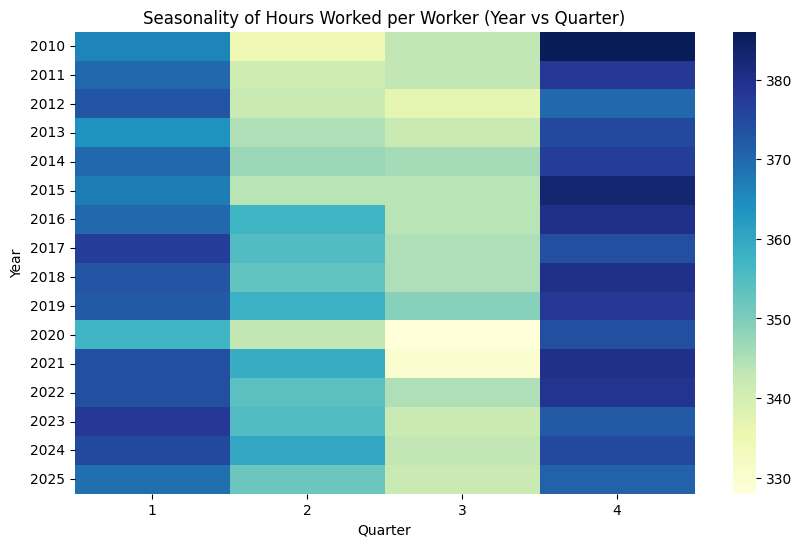

In [20]:
# ==========================================================
# Seasonality Analysis of Labour Intensity
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Prepare dataset for seasonality analysis
# ----------------------------------------------------------

df_season = df_85916NED_clean[
    (df_85916NED_clean["Geslacht_Title"] == "Totaal mannen en vrouwen") &
    (df_85916NED_clean["TypeWerkenden_Title"] == "Totaal") &
    (df_85916NED_clean["frequency"] == "quarterly")
].copy()


# ----------------------------------------------------------
# 1. Seasonal distribution by quarter (boxplot)
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_season,
    x="quarter",
    y="GewerkteUrenPerWerkzamePersoon"
)

plt.title("Seasonal Distribution of Hours Worked per Worker")
plt.xlabel("Quarter")
plt.ylabel("Hours per Worker")

plt.show()


# ----------------------------------------------------------
# 2. Average seasonal cycle (quarterly mean)
# ----------------------------------------------------------

seasonal_cycle = df_season.groupby(
    "quarter",
    observed=False
)["GewerkteUrenPerWerkzamePersoon"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=seasonal_cycle,
    x="quarter",
    y="GewerkteUrenPerWerkzamePersoon",
    marker="o"
)

plt.title("Average Seasonal Cycle of Hours Worked per Worker")
plt.xlabel("Quarter")
plt.ylabel("Average Hours per Worker")

plt.xticks([1,2,3,4])

plt.show()


# ----------------------------------------------------------
# 3. Seasonality heatmap (year vs quarter)
# ----------------------------------------------------------

heatmap_data = df_season.pivot_table(
    values="GewerkteUrenPerWerkzamePersoon",
    index="year",
    columns="quarter",
    observed=False
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Seasonality of Hours Worked per Worker (Year vs Quarter)")
plt.xlabel("Quarter")
plt.ylabel("Year")

plt.show()

Seasonality strength across indicators:


,Indicator,Seasonality_Index
4,GewerkteUrenPerBaan,0.046597
3,GewerkteUrenPerWerkzamePersoon,0.046323
2,GewerkteUren,0.045576
0,WerkzamePersonen,0.007953
1,Banen,0.007563


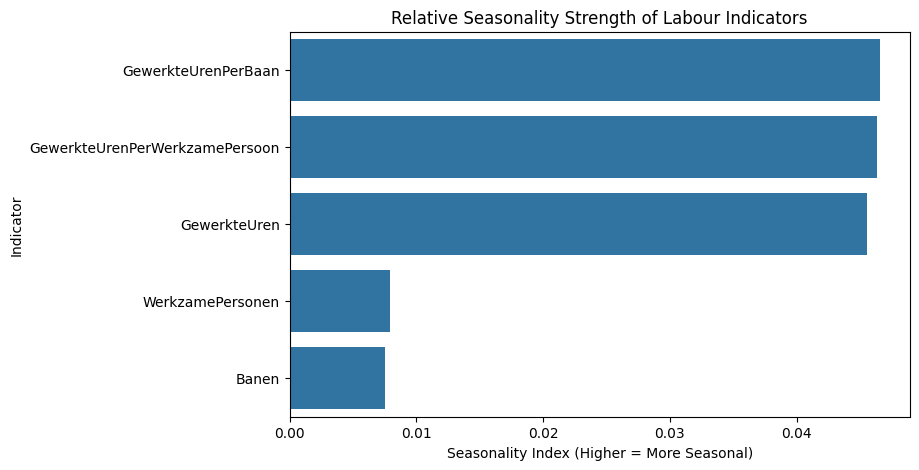

In [21]:
# ==========================================================
# Compare Seasonality Across Labour Indicators
# ==========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Prepare dataset (use total workforce & quarterly data)
# ----------------------------------------------------------

df_season_compare = df_85916NED_clean[
    (df_85916NED_clean["Geslacht_Title"] == "Totaal mannen en vrouwen") &
    (df_85916NED_clean["TypeWerkenden_Title"] == "Totaal") &
    (df_85916NED_clean["frequency"] == "quarterly")
].copy()


# ----------------------------------------------------------
# 2. Indicators to evaluate
# ----------------------------------------------------------

indicators = [
    "WerkzamePersonen",
    "Banen",
    "GewerkteUren",
    "GewerkteUrenPerWerkzamePersoon",
    "GewerkteUrenPerBaan"
]


# ----------------------------------------------------------
# 3. Calculate seasonality strength
# ----------------------------------------------------------

seasonality_results = []

for var in indicators:

    # Average value per quarter
    seasonal_pattern = df_season_compare.groupby(
        "quarter",
        observed=False
    )[var].mean()

    # Seasonality index (coefficient of variation)
    seasonality_index = seasonal_pattern.std() / seasonal_pattern.mean()

    seasonality_results.append({
        "Indicator": var,
        "Seasonality_Index": seasonality_index
    })

seasonality_df = pd.DataFrame(seasonality_results)

# Sort indicators by seasonality strength
seasonality_df = seasonality_df.sort_values(
    "Seasonality_Index",
    ascending=False
)

print("Seasonality strength across indicators:")
display(seasonality_df)


# ----------------------------------------------------------
# 4. Visualize seasonality strength
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=seasonality_df,
    x="Seasonality_Index",
    y="Indicator"
)

plt.title("Relative Seasonality Strength of Labour Indicators")
plt.xlabel("Seasonality Index (Higher = More Seasonal)")
plt.ylabel("Indicator")

plt.show()

#### Interpretation - Seasonality Analysis

The seasonality analysis reveals a clear and consistent quarterly pattern in the average number of hours worked per worker.

Across most years, working hours are highest in the fourth quarter, indicating increased labour activity toward the end of the year. The first quarter also shows relatively high working hours, while the second quarter experiences a moderate decline. The lowest number of hours worked per worker consistently occurs in the third quarter, which likely reflects reduced working hours during the summer holiday period.

The heatmap confirms that this seasonal pattern remains stable across the entire 2010–2025 period, although some deviations are visible in specific years, such as around 2020–2021, which may be associated with disruptions caused by the COVID-19 pandemic.

Overall, the results indicate that labour intensity follows a predictable seasonal cycle, highlighting the importance of accounting for seasonal effects when analyzing labour market dynamics.

Seasonality Comparison Across Labour Indicators

The seasonality comparison shows that working-hour related indicators exhibit the strongest seasonal variation in the labour market. Indicators such as hours worked per job, hours worked per worker, and total hours worked display noticeably higher seasonality indices, indicating that labour intensity fluctuates across quarters due to factors such as holidays, seasonal economic activity, and business cycles.

In contrast, employment indicators such as the number of employed persons and the number of jobs show very low seasonal variation. This suggests that workforce size tends to change gradually over time rather than following a seasonal pattern. Overall, the results indicate that seasonal dynamics in the labour market are primarily driven by changes in working hours rather than changes in the number of workers or jobs.

### Correlation Heatmap of Labour Indicators

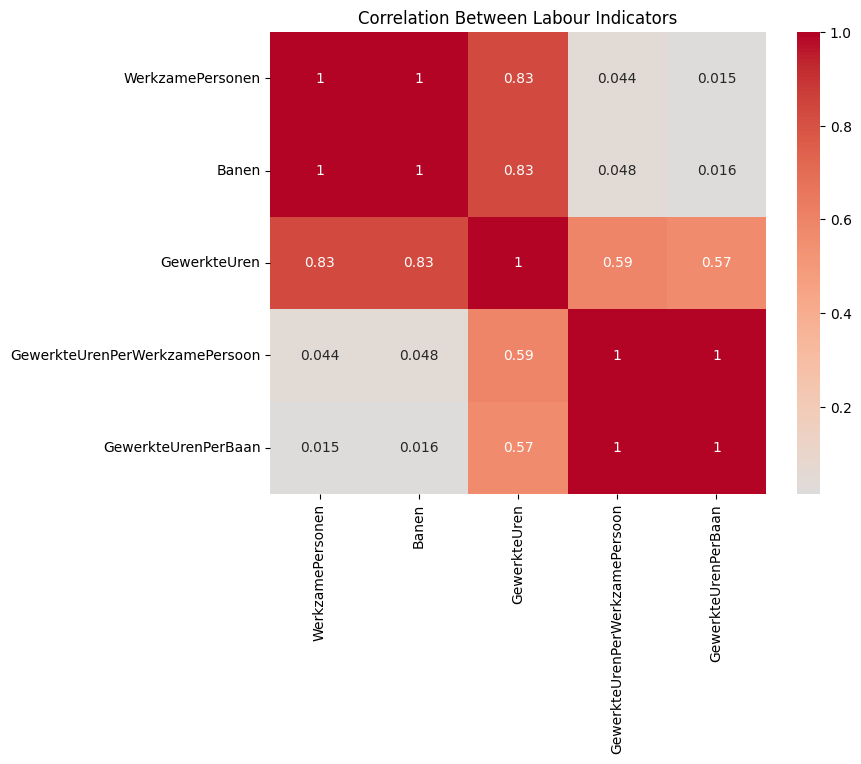

In [22]:
# ----------------------------------------------------------
# Correlation between labour indicators
# ----------------------------------------------------------

df_corr = df_85916NED_clean[
    (df_85916NED_clean["Geslacht_Title"] == "Totaal mannen en vrouwen") &
    (df_85916NED_clean["TypeWerkenden_Title"] == "Totaal") &
    (df_85916NED_clean["frequency"] == "quarterly")
]

corr_vars = [
    "WerkzamePersonen",
    "Banen",
    "GewerkteUren",
    "GewerkteUrenPerWerkzamePersoon",
    "GewerkteUrenPerBaan"
]

corr_matrix = df_corr[corr_vars].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Labour Indicators")

plt.show()

#### Interpretation Correlation Heatmap of Labour Indicators

The correlation analysis reveals several strong relationships between the labour market indicators.

First, the number of employed persons and the number of jobs show an almost perfect correlation (≈1.0). This indicates that these two variables move almost identically over time. As employment increases, the number of jobs increases proportionally. This is expected because both indicators capture overall labour market size.

Second, total hours worked shows a strong positive correlation (≈0.83) with both employment and jobs. This suggests that increases in the workforce are strongly associated with increases in total labour input. In other words, when more people are employed, the total number of hours worked in the economy also rises.

In contrast, the average hours worked per worker and per job show very weak correlations with the number of employed persons and jobs. This indicates that labour intensity (how many hours individuals work) varies largely independently from changes in workforce size.

Finally, hours worked per worker and hours worked per job are almost perfectly correlated (≈1.0). This suggests that these two indicators capture very similar information about labour intensity in the economy and may therefore be somewhat redundant in analytical models.

Overall, the correlation structure indicates that the labour market can be broadly characterized by two distinct dimensions: workforce size (employment and jobs) and labour intensity (hours worked per worker or job).

### Jobs per Worker (Labour Market Structure Indicator)

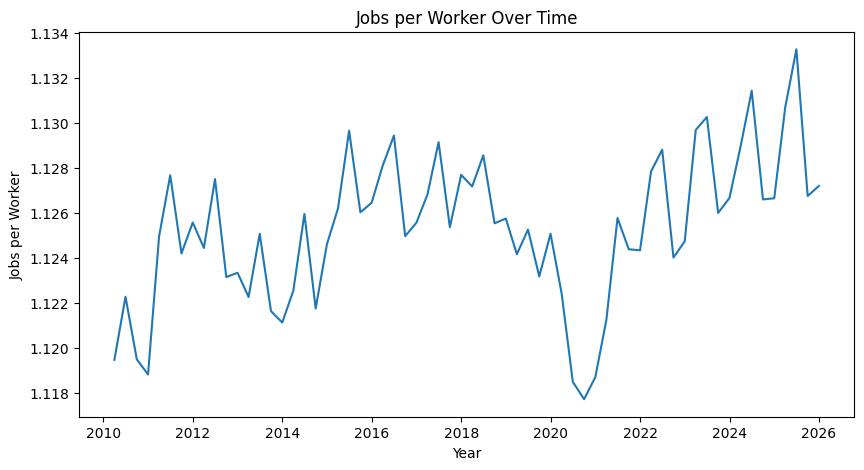

In [23]:
# ----------------------------------------------------------
# Jobs per worker trend
# ----------------------------------------------------------

df_jobs = df_corr.copy()

df_jobs["Jobs_per_Worker"] = (
    df_jobs["Banen"] / df_jobs["WerkzamePersonen"]
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_jobs,
    x="period_enddate",
    y="Jobs_per_Worker"
)

plt.title("Jobs per Worker Over Time")
plt.xlabel("Year")
plt.ylabel("Jobs per Worker")

plt.show()

#### Interpretation - Jobs per Worker (Labour Market Structure Indicator)

The jobs-per-worker indicator measures the average number of jobs held per employed person and provides insight into labour market structure and job fragmentation.

The results show that the value remains relatively stable over the observed period, fluctuating slightly between approximately 1.12 and 1.13 jobs per worker. This indicates that, on average, some workers hold more than one job, but the prevalence of multiple job holding in the labour market has remained fairly consistent over time.

A temporary decline is visible around 2020–2021, which may reflect disruptions in labour market activity during the COVID-19 pandemic. After this period, the indicator gradually increases again, suggesting a recovery in labour market dynamics.

Overall, the trend suggests that while the total number of jobs and workers has increased over time, the structural relationship between jobs and workers has remained relatively stable, indicating no major shift toward widespread multi-job holding in the Dutch labour market during this period


# Summary and Key Insights

Dataset overview

This notebook explored the CBS labour market dataset 85916NED, covering the period 2010–2025.
The dataset contains quarterly labour volume indicators by gender and worker type in the Netherlands.

The main indicators analysed were:

WerkzamePersonen – number of employed persons

Banen – number of jobs

GewerkteUren – total hours worked

GewerkteUrenPerWerkzamePersoon – hours worked per worker

GewerkteUrenPerBaan – hours worked per job

These indicators were analysed across:

time

gender (Mannen vs Vrouwen)

worker type (Werknemers vs Zelfstandigen)

The analysis focused on understanding labour market structure, labour intensity, and seasonal labour patterns.

Key Insights
1. Continued labour market growth

The number of employed persons and total hours worked show a clear upward trend between 2010 and 2025, indicating steady expansion of the Dutch labour market.

Employment growth becomes particularly visible after 2015, with the labour market recovering quickly after the COVID-19 shock in 2020–2021.

Implication for modelling

Strong labour market growth may increase labour demand and work pressure, which can potentially influence absenteeism patterns.

2. Stable labour market structure

The Dutch labour market is strongly dominated by employees (Werknemers).

Throughout the observed period:

Employees represent roughly 83–85% of the workforce

Self-employed workers (Zelfstandigen) represent approximately 15–17%

Although both groups increased in absolute numbers, the relative composition of the labour market remained relatively stable over time.

Implication

Worker type composition may still be relevant for modelling, as self-employed workers may exhibit different sick leave behaviour or reporting patterns compared to employees.

3. Increasing female participation in the labour market

Employment trends show that both male and female employment increased steadily over time.

However, female employment grew slightly faster, leading to a gradual narrowing of the gender employment gap.

This reflects structural labour market changes such as:

increasing female labour force participation

growth of part-time employment

improved labour market integration of women

Implication

Gender composition may influence sick leave patterns and labour market dynamics.

4. Labour intensity varies more than workforce size

Correlation analysis shows that:

WerkzamePersonen and Banen are almost perfectly correlated, indicating that both variables primarily capture labour market size.

Indicators related to working hours (GewerkteUren, hours per worker, hours per job) behave differently and represent labour intensity rather than workforce size.

This suggests that labour market dynamics can be understood through two main dimensions:

Workforce size (employment and jobs)

Labour intensity (working hours)

Implication

Working-hour indicators may capture changes in labour demand or work pressure, which could influence absenteeism behaviour.

5. Strong seasonal labour patterns

Seasonality analysis reveals clear quarterly labour patterns.

Across most years:

Q4 shows the highest labour intensity

Q3 shows the lowest working hours per worker

This pattern is likely explained by summer holiday periods and seasonal economic activity.

Seasonality is much stronger in working-hour indicators than in employment indicators.

Implication

Seasonal features (e.g., quarter indicators) should be included when modelling labour market related phenomena such as sick leave.

6. Stable jobs-per-worker ratio

The jobs-per-worker indicator remains relatively stable between 1.12 and 1.13 over the observed period.

This suggests that:

some workers hold multiple jobs

but the prevalence of multiple job holding has not changed significantly over time

Implication

The structural relationship between jobs and workers remains stable, indicating no major shift toward widespread multi-job holding in the labour market.

Potential Features for Sick Leave Prediction

The explored labour indicators can be used to construct modelling features such as:

Macro labour indicators

total employment

total hours worked

jobs per worker

hours per worker

Labour market structure

share of Werknemers vs Zelfstandigen

gender employment composition

Labour intensity

hours worked per worker

hours worked per job

Temporal features

year trend

quarter (seasonality)

Conclusion

The labour market dataset provides valuable macro-economic and structural indicators describing workforce size, labour intensity, and labour market composition in the Netherlands.

The analysis shows that the Dutch labour market experienced steady employment growth, increasing female participation, stable worker composition, and strong seasonal variation in working hours.

These labour indicators can provide useful contextual features for sick leave prediction models, as they capture underlying labour market conditions that may influence absenteeism behaviour.